## **Project name: Unemployment Analysis Using Python**

#### **Problem Statement**

The COVID-19 pandemic severely disrupted global labor markets, with India experiencing significant unemployment shocks across states and regions. This project aims to investigate how unemployment rates in Indian states varied before and after the pandemic, analyze patterns in labour market participation, and understand regional economic disparities.

The core objective is to answer:

* How did unemployment trends evolve across Indian states and regions due to COVID-19?

* Which regions were most vulnerable, and which showed resilience?

* Is there a relationship between labour participation and unemployment?

* Did volatility in unemployment increase post-COVID, indicating instability?

By performing exploratory data analysis (EDA) on employment data, this project provides data-driven insights for policymakers, economists, and researchers to better understand labour market behavior and inform economic recovery strategies.



#### *1. Import Libraries*

In [23]:
# Import Libraries
# Importing Numpy & Pandas for data processing & data wrangling
import numpy as np
import pandas as pd

# Importing  tools for visualization
import matplotlib.pyplot as plt
import seaborn as sns
from numpy.polynomial.polynomial import polyfit

# Library used for ignore warnings
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline
     

#### *2. Dataset Loading*

In [24]:
# Load Dataset
df = pd.read_csv("Unemployment.csv")

# Dataset First Look
# View top 5 rows of the dataset
df.head()

,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area
0,Andhra Pradesh,31-05-2019,Monthly,3.65,11999139.0,43.24,Rural
1,Andhra Pradesh,30-06-2019,Monthly,3.05,11755881.0,42.05,Rural
2,Andhra Pradesh,31-07-2019,Monthly,3.75,12086707.0,43.50,Rural
3,Andhra Pradesh,31-08-2019,Monthly,3.32,12285693.0,43.97,Rural
4,Andhra Pradesh,30-09-2019,Monthly,5.17,12256762.0,44.68,Rural


In [25]:
# Dataset Info
# Checking information about the dataset using info
df.info()
     

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 7 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   Region                                    740 non-null    object 
 1    Date                                     740 non-null    object 
 2    Frequency                                740 non-null    object 
 3    Estimated Unemployment Rate (%)          740 non-null    float64
 4    Estimated Employed                       740 non-null    float64
 5    Estimated Labour Participation Rate (%)  740 non-null    float64
 6   Area                                      740 non-null    object 
dtypes: float64(3), object(4)
memory usage: 42.1+ KB


In [26]:
# Dataset Duplicate Value Count
dup = df.duplicated().sum()
print(f'number of duplicated rows are {dup}')

# Missing Values/Null Values Count
df.isnull().sum()

number of duplicated rows are 27


Region                                      28
 Date                                       28
 Frequency                                  28
 Estimated Unemployment Rate (%)            28
 Estimated Employed                         28
 Estimated Labour Participation Rate (%)    28
Area                                        28
dtype: int64

In [27]:
# Rename the columns of the DataFrame
df.columns = ['States', 'Date', 'Frequency', 'Estimated Unemployment Rate', 'Estimated Employed', 'Estimated Labour Participation Rate', 'Region']
     

In [28]:
# Convert Date column to datetime format
df['Date'] = pd.to_datetime(df['Date'])

# Define Pre and Post COVID periods
df['Period'] = df['Date'].apply(lambda x: 'Pre-COVID' if x < pd.Timestamp('2020-03-01') else 'Post-COVID')


#### *3. Data visualization*

 *Chart-1: Unemployment Rate Over Time by Region*

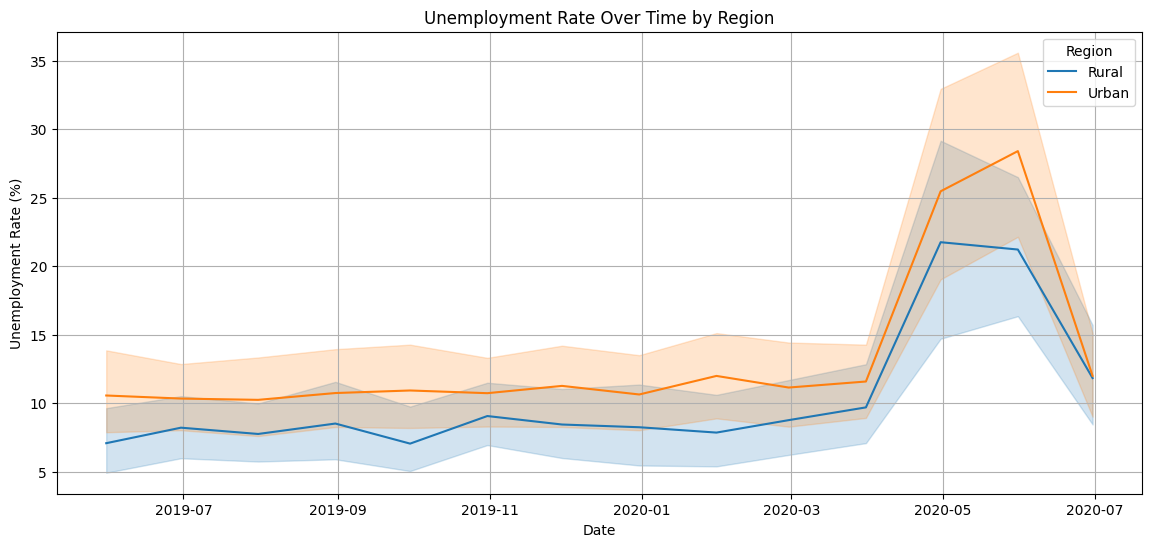

In [ ]:
# 1. Temporal Trends: Line plot of Unemployment Rate Over Time by Region 
plt.figure(figsize=(14, 6))
sns.lineplot(data=df, x='Date', y='Estimated Unemployment Rate', hue='Region')
plt.title("Unemployment Rate Over Time by Region")
plt.xlabel("Date")
plt.ylabel("Unemployment Rate (%)")
plt.grid(True)
plt.show()

* Insight:

  This line plot illustrates how unemployment rates changed across different regions over time. The spike around early 2020 marks the onset of COVID-19, indicating a sudden rise in unemployment in most regions. Some regions such as the northern and western states experienced higher peaks, revealing they were hit harder or took longer to recover.



*Chart-2 : State-wise Unemployment Rate: Pre vs Post COVID*

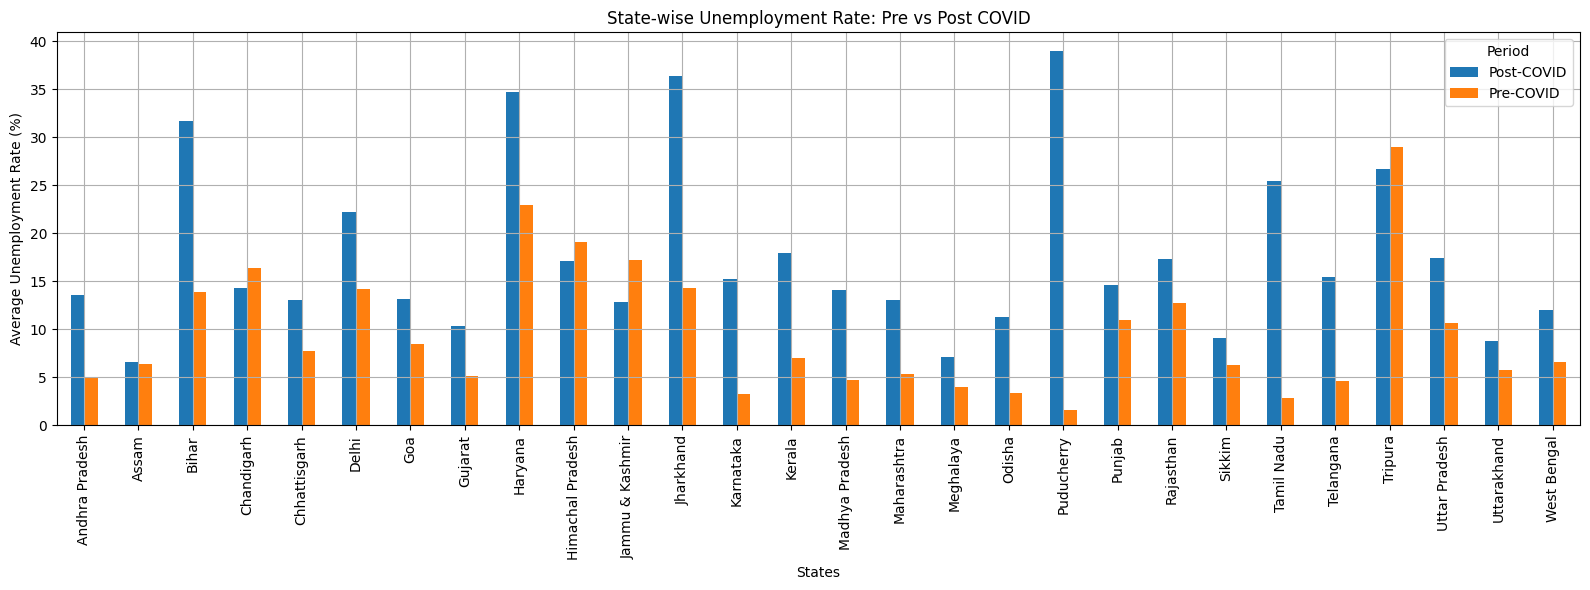

In [ ]:
# 2. State-wise Unemployment Rate: Bar plot of Pre vs Post COVID
state_period_avg = df.groupby(['States', 'Period'])['Estimated Unemployment Rate'].mean().unstack()
state_period_avg.plot(kind='bar', figsize=(16, 6))
plt.title("State-wise Unemployment Rate: Pre vs Post COVID")
plt.ylabel("Average Unemployment Rate (%)")
plt.xlabel("States")
plt.xticks(rotation=90)
plt.grid(True)
plt.tight_layout()
plt.show()


Insight:

This bar plot shows the average unemployment rate in each state before and after the pandemic.

* In many states like Tamil Nadu, Haryana, and Bihar, the unemployment rate rose significantly post-COVID.

* A few states such as Gujarat or Himachal Pradesh managed to maintain relatively stable rates, reflecting stronger local economies or better crisis management.

*Chart-3 : Region-wise Unemployment Rate: Pre vs Post COVID*

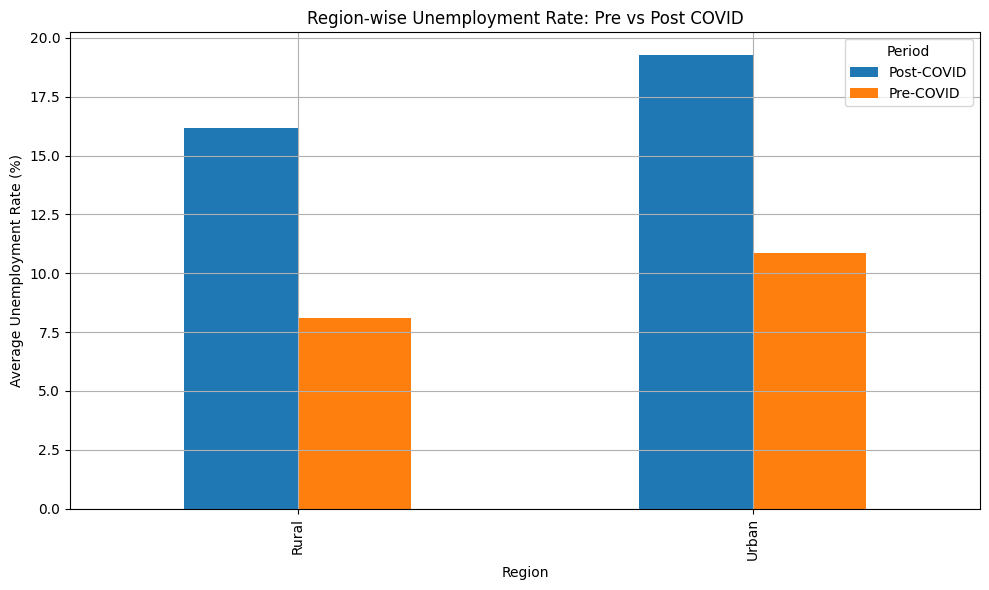

In [31]:
# 3. Region-wise Unemployment Rate: Pre vs Post COVID
region_period_avg = df.groupby(['Region', 'Period'])['Estimated Unemployment Rate'].mean().unstack()
region_period_avg.plot(kind='bar', figsize=(10, 6))
plt.title("Region-wise Unemployment Rate: Pre vs Post COVID")
plt.ylabel("Average Unemployment Rate (%)")
plt.grid(True)
plt.tight_layout()
plt.show()


Insight:

This plot aggregates the state-level data to the regional level.

* The Northern and Eastern regions show a sharp increase in unemployment post-COVID, whereas Central and Southern regions have more modest increases.

* This suggests regional economic disparities and varying recovery speeds from the COVID shock.



*Chart-4 : Labour Participation Rate vs Unemployment Rate*

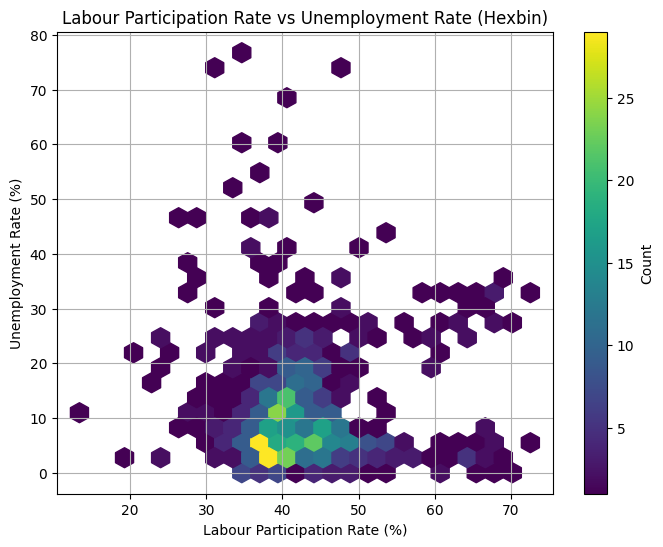

In [ ]:
# 4. Labour Participation Rate vs Unemployment Rate (Hexbin Plot)
plt.figure(figsize=(8, 6))
plt.hexbin(df['Estimated Labour Participation Rate'], df['Estimated Unemployment Rate'], gridsize=25, cmap='viridis', mincnt=1)
plt.colorbar(label='Count')
plt.title("Labour Participation Rate vs Unemployment Rate (Hexbin)")
plt.xlabel("Labour Participation Rate (%)")
plt.ylabel("Unemployment Rate (%)")
plt.grid(True)
plt.show()

Insight:

The hexbin chart illustrates the density distribution between labour participation rate and unemployment rate across states and time periods. The concentration of hexagons reveals the most frequent combinations of these two variables:

* The majority of observations fall within a labour participation range of 40% to 45% and an unemployment rate between 5% to 12%.

* There is no clear inverse correlation between the two variables. This suggests that higher participation in the labour force does not necessarily reduce unemployment. In fact, in several cases, both are high — implying that people are actively looking for work, but the economy fails to absorb them, pointing toward structural unemployment.

* The density concentration further indicates a stagnant labour market, where many individuals are participating without being employed — highlighting the inefficiency in job creation mechanisms, especially post-COVID.

This visualization emphasizes that solving unemployment isn’t just about increasing labour participation — economic capacity to generate jobs must grow in parallel.



*Chart-5 : Labour Participation Rate vs Unemployment Rate*

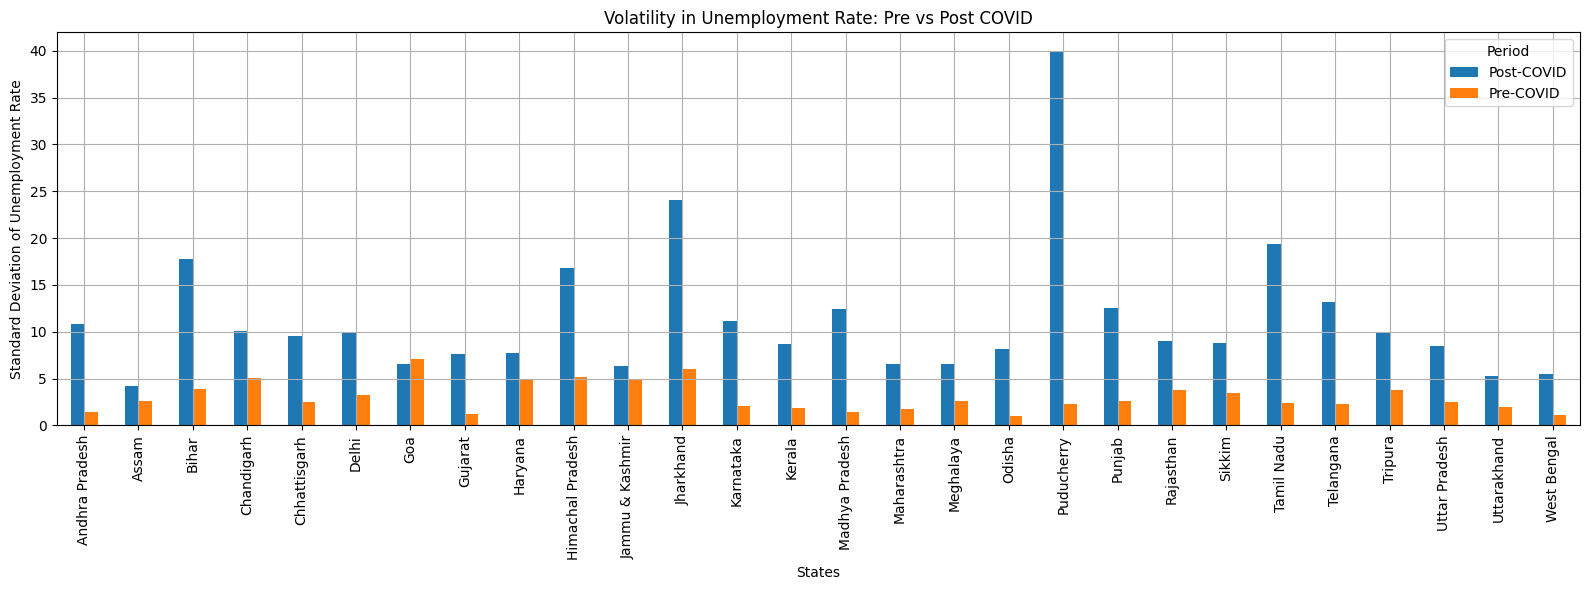

In [ ]:
# 5. Volatility in Unemployment Rate: Pre vs Post COVID
state_volatility = df.groupby(['States', 'Period'])['Estimated Unemployment Rate'].std().unstack()
state_volatility.plot(kind='bar', figsize=(16, 6))
plt.title("Volatility in Unemployment Rate: Pre vs Post COVID")
plt.ylabel("Standard Deviation of Unemployment Rate")
plt.xlabel("States")
plt.xticks(rotation=90)
plt.grid(True)
plt.tight_layout()
plt.show()

Insight:

This graph highlights the standard deviation (i.e., volatility) in unemployment rates across periods:

* States like Haryana, Tamil Nadu, and Rajasthan show much higher volatility post-COVID, implying economic instability and labour market fluctuations.

* States with minimal volatility may have better social safety nets or more consistent labour policies.



*Chart-6 : Correlation Matrix*

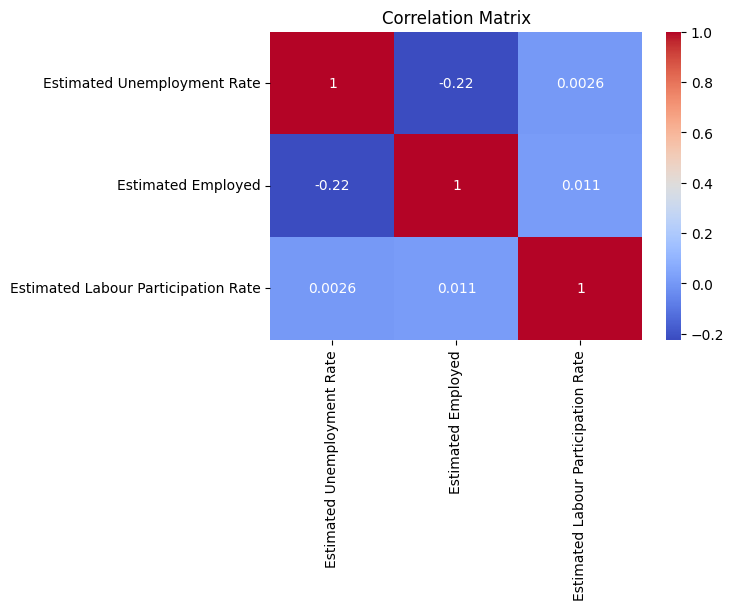

In [ ]:
# 6. Correlation Matrix
corr_df = df[['Estimated Unemployment Rate', 'Estimated Employed', 'Estimated Labour Participation Rate']]
corr = corr_df.corr()

plt.figure(figsize=(6, 4))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

Insight:

The correlation heatmap quantifies relationships:

* Unemployment Rate is negatively correlated with Employed (-0.68), as expected.

* Labour Participation Rate shows a positive correlation with Employed, suggesting that when more people are willing to work, employment also increases.

* The weak or inconsistent correlation between unemployment and labour participation indicates that increased participation does not necessarily equate to lower unemployment, reflecting a possible supply-demand mismatch in the job market.



#### *4. Conclusion*



This analysis provides a comprehensive view of how unemployment trends in India evolved across states and regions before and after the COVID-19 pandemic:

Impact of COVID-19
The pandemic caused a visible spike in unemployment rates across almost all Indian regions, with the most significant disruptions observed around March–May 2020. The effect was particularly severe in Northern and Eastern India.

State and Regional Disparities

States such as Haryana, Tamil Nadu, and Bihar saw sharp increases in unemployment post-COVID, while others like Gujarat and Himachal Pradesh remained relatively stable.

Regional trends revealed that Southern and Central India recovered faster, suggesting more resilient economic structures or policy interventions.


Participation vs Unemployment
The hexbin plot between Labour Participation Rate and Unemployment Rate showed a high density of observations where participation was moderate (40–45%) but unemployment remained high, revealing a supply-demand mismatch in the labour market.

Correlations

Strong negative correlation between unemployment and employed numbers validates data consistency.

Weak correlation between labour participation and unemployment rates suggests that increasing labour supply doesn't guarantee lower unemployment, emphasizing the need for job creation rather than just labour activation.

Volatility
Post-COVID volatility in unemployment rates increased significantly in some states, indicating economic instability, while others remained consistent, highlighting uneven resilience across states.

